In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
df = pd.read_csv("weather_data.csv")

print(df.head())
print(df.info())

       Location            Date_Time  Temperature_C  Humidity_pct  \
0     San Diego  2024-01-14 21:12:46      10.683001     41.195754   
1     San Diego  2024-05-17 15:22:10       8.734140     58.319107   
2     San Diego  2024-05-11 09:30:59      11.632436     38.820175   
3  Philadelphia  2024-02-26 17:32:39      -8.628976     54.074474   
4   San Antonio  2024-04-29 13:23:51      39.808213     72.899908   

   Precipitation_mm  Wind_Speed_kmh  
0          4.020119        8.233540  
1          9.111623       27.715161  
2          4.607511       28.732951  
3          3.183720       26.367303  
4          9.598282       29.898622  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Location          1000000 non-null  object 
 1   Date_Time         1000000 non-null  object 
 2   Temperature_C     1000000 non-null  float64
 

In [8]:
df["Date_Time"] = pd.to_datetime(df["Date_Time"])

df["Year"] = df["Date_Time"].dt.year
df["Month"] = df["Date_Time"].dt.month
df["Day"] = df["Date_Time"].dt.day
df["Hour"] = df["Date_Time"].dt.hour

In [9]:
encoder = LabelEncoder()

df["Location"] = encoder.fit_transform(df["Location"])

In [10]:
X = df[[
    "Location",
    "Humidity_pct",
    "Precipitation_mm",
    "Wind_Speed_kmh",
    "Year",
    "Month",
    "Day",
    "Hour"
]]

y = df["Temperature_C"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

In [14]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE : 12.517845719344805
MSE : 209.26286666722422
RMSE: 14.46592087173244
R² Score: 0.0003838715322781461


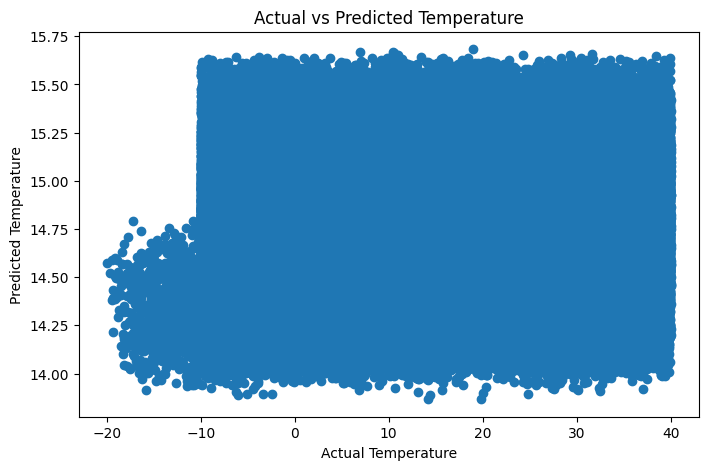

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")

plt.show()

In [16]:
print("Available Locations:")
print(encoder.classes_)

Available Locations:
['Chicago' 'Dallas' 'Houston' 'Los Angeles' 'New York' 'Philadelphia'
 'Phoenix' 'San Antonio' 'San Diego' 'San Jose']


In [17]:
location = encoder.transform(["San Diego"])[0]

humidity = float(input("Humidity (%): "))
precipitation = float(input("Precipitation (mm): "))
wind = float(input("Wind Speed (km/h): "))
year = int(input("Year: "))
month = int(input("Month: "))
day = int(input("Day: "))
hour = int(input("Hour (0-23): "))

new_data = [[
    location,
    humidity,
    precipitation,
    wind,
    year,
    month,
    day,
    hour
]]

prediction = model.predict(new_data)

print("Predicted Temperature:", round(prediction[0],2),"°C")

Humidity (%): 62
Precipitation (mm): 3
Wind Speed (km/h): 15
Year: 2024
Month: 7
Day: 10
Hour (0-23): 14
Predicted Temperature: 15.49 °C


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
